# Normative Simulacra: Norm & Flow Distribution Analysis

Publication-ready plots for the COLM 2026 paper examining:
1. Deontic force distributions (overall & by book)
2. Top contexts for norms (overall & by book)
3. Top contexts for information flows (overall & by book)
4. Cross-cutting analyses: context overlap, appropriateness patterns, normative diversity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from scipy.stats import entropy

# ── Paths ──
DATA_DIR = Path("/share/pierson/matt/n2s4cir/data/fiction10")
FIG_DIR = Path("/share/pierson/matt/UAIR/papers/colm26_normative-simulacra/figures")
FIG_DIR.mkdir(exist_ok=True)

# ── Load data ──
norms = pd.read_parquet(DATA_DIR / "abstracted_norms.parquet")
flows = pd.read_parquet(DATA_DIR / "ci_flows.parquet")

print(f"Norms: {len(norms):,} | Flows: {len(flows):,}")
print(f"Books: {norms['book_title'].nunique()}")

Norms: 11,869 | Flows: 1,241
Books: 10


In [2]:
# ── Style config ──
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Consistent book short names & ordering (by corpus size desc)
BOOK_ORDER = [
    "Les Misérables",
    "The Count of Monte Cristo",
    "Bleak House",
    "Middlemarch",
    "Anna Karenina",
    "Pride and Prejudice",
    "Nineteen Eighty-Four",
    "The Age of Innocence",
    "The Picture of Dorian Gray",
    "Alice's Adventures in Wonderland",
]

BOOK_SHORT = {
    "Les Misérables": "Les Mis.",
    "The Count of Monte Cristo": "Monte Cristo",
    "Bleak House": "Bleak House",
    "Middlemarch": "Middlemarch",
    "Anna Karenina": "Anna Kar.",
    "Pride and Prejudice": "Pride & Prej.",
    "Nineteen Eighty-Four": "1984",
    "The Age of Innocence": "Age of Inn.",
    "The Picture of Dorian Gray": "Dorian Gray",
    "Alice's Adventures in Wonderland": "Alice",
}

# Deontic force palette (semantic ordering: obligation → prohibition)
DEONTIC_ORDER = ["obligatory", "recommended", "permitted", "discouraged", "prohibited"]
DEONTIC_COLORS = {
    "obligatory": "#b2182b",   # strong red
    "recommended": "#ef8a62",  # light red
    "permitted": "#f7f7f7",    # neutral gray
    "discouraged": "#67a9cf",  # light blue
    "prohibited": "#2166ac",   # strong blue
}

# Warm sequential cmap matching paper heatmap
CMAP_WARM = "YlOrRd"

In [3]:
# ── Normalize context labels (case-insensitive dedup) ──
norms["context"] = norms["raz_context"].str.strip().str.lower()
flows["context"] = flows["ci_context"].str.strip().str.lower()

# Normalize deontic force
norms["deontic"] = norms["raz_normative_force"].str.strip().str.lower()

# Add short book names
norms["book"] = norms["book_title"].map(BOOK_SHORT)
flows["book"] = flows["book_title"].map(BOOK_SHORT)

book_short_order = [BOOK_SHORT[b] for b in BOOK_ORDER]

print("Deontic forces:", norms["deontic"].value_counts().to_dict())
print(f"Norm contexts (unique): {norms['context'].nunique()}")
print(f"Flow contexts (unique): {flows['context'].nunique()}")

Deontic forces: {'obligatory': 5377, 'recommended': 3477, 'prohibited': 1740, 'permitted': 541, 'discouraged': 419}
Norm contexts (unique): 1065
Flow contexts (unique): 148


---
## 1. Deontic Force Distribution

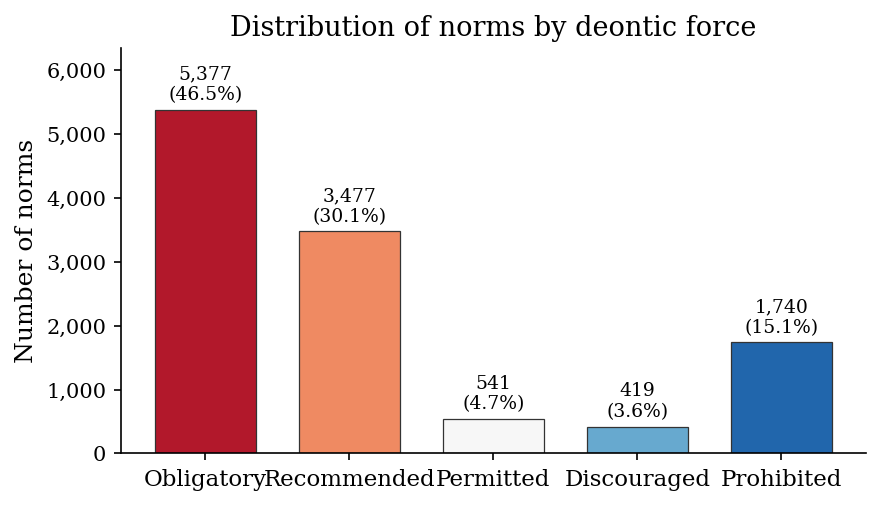

In [4]:
# ── Fig 1a: Overall deontic force distribution ──
deontic_counts = norms["deontic"].value_counts().reindex(DEONTIC_ORDER)

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(
    range(len(DEONTIC_ORDER)),
    deontic_counts.values,
    color=[DEONTIC_COLORS[d] for d in DEONTIC_ORDER],
    edgecolor="#333333",
    linewidth=0.6,
    width=0.7,
)
ax.set_xticks(range(len(DEONTIC_ORDER)))
ax.set_xticklabels([d.capitalize() for d in DEONTIC_ORDER], fontsize=11)
ax.set_ylabel("Number of norms")
ax.set_title("Distribution of norms by deontic force")

# Add count + percentage labels
total = deontic_counts.sum()
for bar, val in zip(bars, deontic_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.008,
        f"{val:,}\n({val/total:.1%})",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_ylim(0, deontic_counts.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
fig.savefig(FIG_DIR / "deontic_force_overall.pdf")
plt.show()

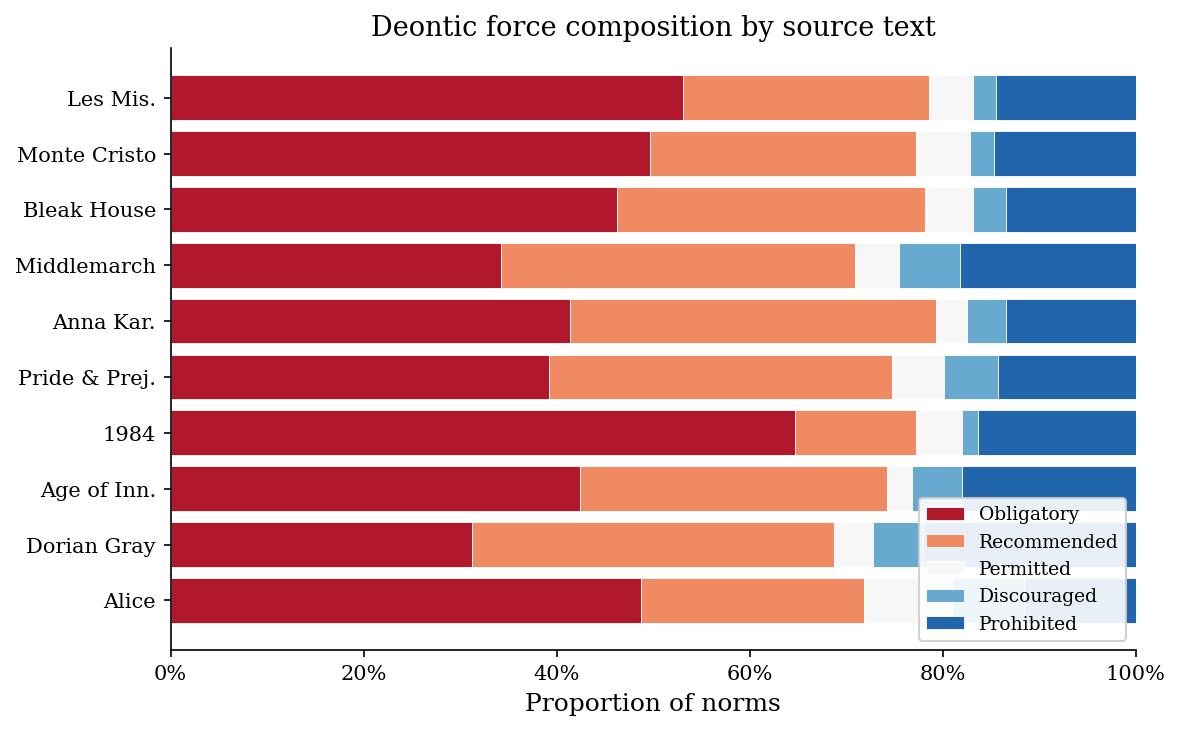

deontic,obligatory,recommended,permitted,discouraged,prohibited,total
book_title,,,,,,
Les Misérables,1539,738,132,68,419,2896
The Count of Monte Cristo,1016,563,115,50,301,2045
Bleak House,811,561,86,61,235,1754
Middlemarch,520,557,70,96,276,1519
Anna Karenina,542,495,42,54,175,1308
Pride and Prejudice,261,237,36,37,95,666
Nineteen Eighty-Four,381,74,28,10,96,589
The Age of Innocence,163,122,10,20,69,384
The Picture of Dorian Gray,85,102,11,14,60,272


In [5]:
# ── Fig 1b: Deontic force proportions by book (normalized stacked bar) ──
cross = pd.crosstab(norms["book_title"], norms["deontic"])
cross = cross.reindex(index=BOOK_ORDER, columns=DEONTIC_ORDER).fillna(0)
cross_pct = cross.div(cross.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(BOOK_ORDER))
short_labels = [BOOK_SHORT[b] for b in BOOK_ORDER]

for d in DEONTIC_ORDER:
    vals = cross_pct[d].values
    ax.barh(
        range(len(BOOK_ORDER)), vals, left=bottom,
        color=DEONTIC_COLORS[d], edgecolor="white", linewidth=0.4,
        label=d.capitalize(),
    )
    bottom += vals

ax.set_yticks(range(len(BOOK_ORDER)))
ax.set_yticklabels(short_labels)
ax.set_xlabel("Proportion of norms")
ax.set_title("Deontic force composition by source text")
ax.legend(loc="lower right", frameon=True, framealpha=0.9, ncol=1)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG_DIR / "deontic_force_by_book.pdf")
plt.show()

# Print the raw counts for reference
cross["total"] = cross.sum(axis=1)
cross

---
## 2. Norm Contexts (Top 20)

/tmp/ipykernel_2649849/110656133.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(CMAP_WARM)(np.linspace(0.25, 0.85, len(top_norm_ctx)))


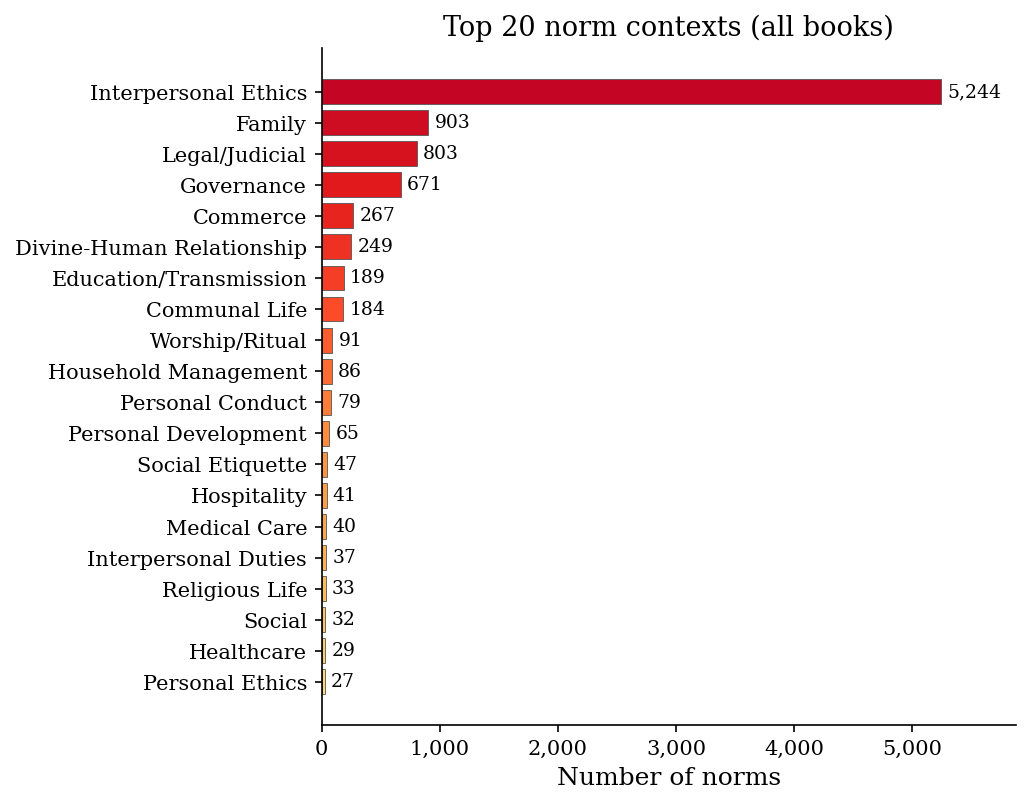

In [6]:
# ── Fig 2a: Top 20 norm contexts overall ──
top_norm_ctx = norms["context"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = plt.cm.get_cmap(CMAP_WARM)(np.linspace(0.25, 0.85, len(top_norm_ctx)))
ax.barh(
    range(len(top_norm_ctx)),
    top_norm_ctx.values,
    color=colors[::-1],
    edgecolor="#555555",
    linewidth=0.4,
)
ax.set_yticks(range(len(top_norm_ctx)))
ax.set_yticklabels([c.title() for c in top_norm_ctx.index], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Number of norms")
ax.set_title("Top 20 norm contexts (all books)")

# Annotate counts
for i, v in enumerate(top_norm_ctx.values):
    ax.text(v + top_norm_ctx.max() * 0.01, i, f"{v:,}", va="center", fontsize=9)

ax.set_xlim(0, top_norm_ctx.max() * 1.12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
fig.savefig(FIG_DIR / "norm_contexts_top20.pdf")
plt.show()

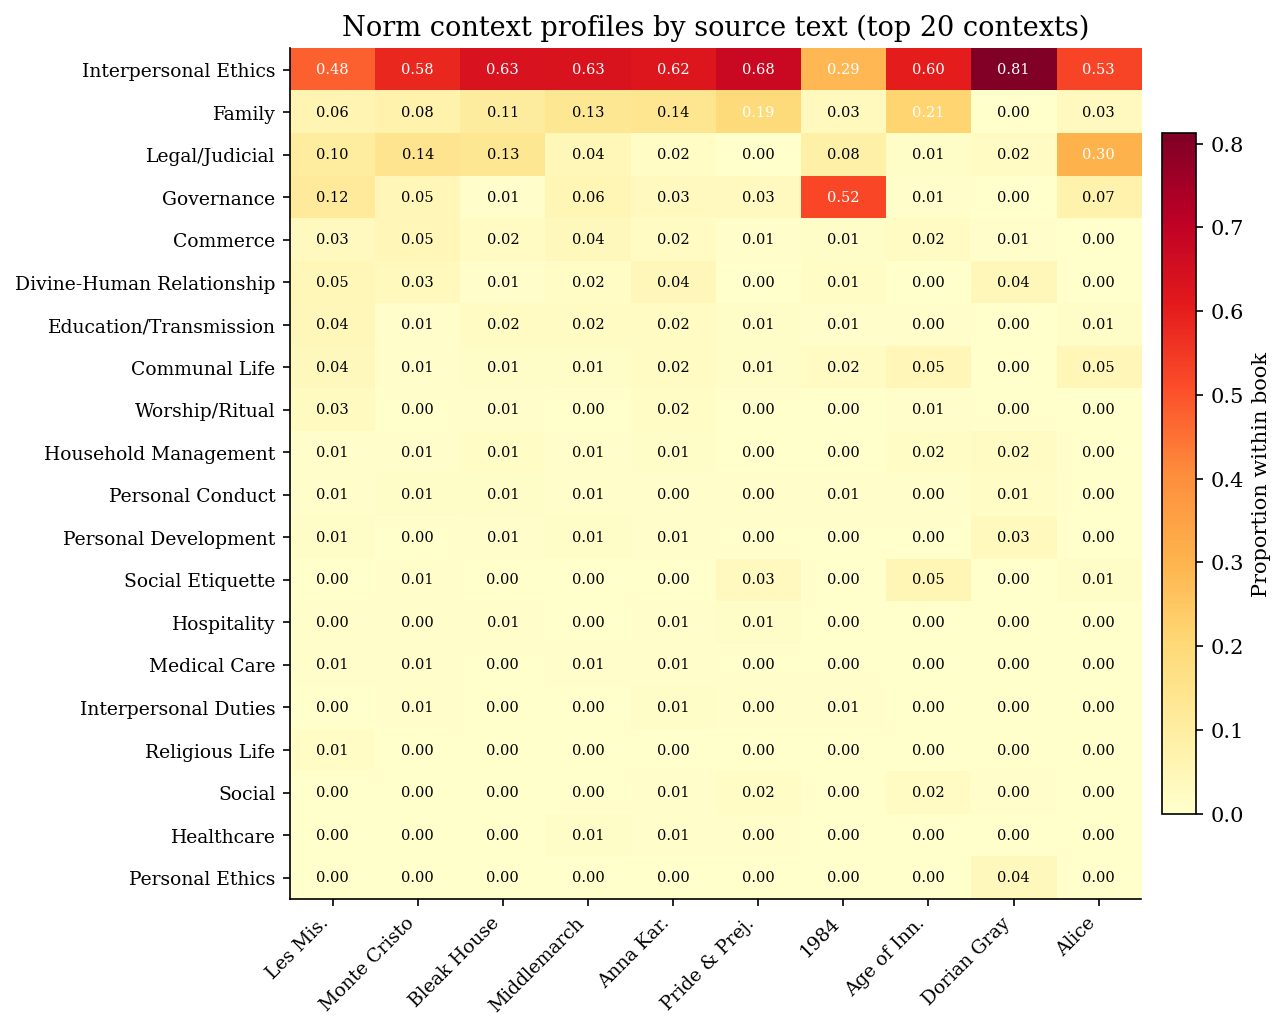

In [7]:
# ── Fig 2b: Top 20 norm contexts × book heatmap ──
top20_norm_labels = top_norm_ctx.index.tolist()

cross_norm_ctx = pd.crosstab(norms["context"], norms["book_title"])
cross_norm_ctx = cross_norm_ctx.reindex(index=top20_norm_labels, columns=BOOK_ORDER).fillna(0)

# Normalize per-book (column-wise) to show context emphasis within each book
cross_norm_pct = cross_norm_ctx.div(cross_norm_ctx.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cross_norm_pct.values, cmap=CMAP_WARM, aspect="auto")

ax.set_xticks(range(len(BOOK_ORDER)))
ax.set_xticklabels([BOOK_SHORT[b] for b in BOOK_ORDER], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(top20_norm_labels)))
ax.set_yticklabels([c.title() for c in top20_norm_labels], fontsize=9)

# Annotate cells
for i in range(len(top20_norm_labels)):
    for j in range(len(BOOK_ORDER)):
        val = cross_norm_pct.values[i, j]
        color = "white" if val > 0.15 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Proportion within book", fontsize=10)
ax.set_title("Norm context profiles by source text (top 20 contexts)")
plt.tight_layout()
fig.savefig(FIG_DIR / "norm_contexts_by_book_heatmap.pdf")
plt.show()

---
## 3. Information Flow Contexts (Top 20)

/tmp/ipykernel_2649849/1847580009.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(CMAP_WARM)(np.linspace(0.25, 0.85, len(top_flow_ctx)))


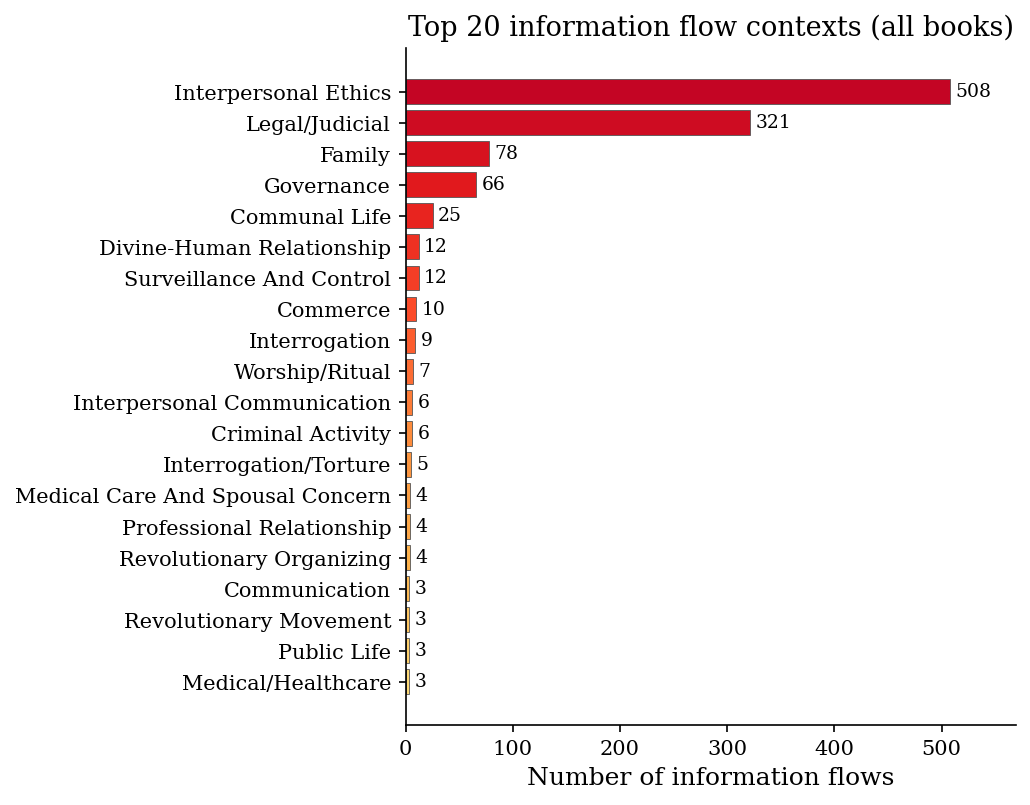

In [8]:
# ── Fig 3a: Top 20 flow contexts overall ──
top_flow_ctx = flows["context"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = plt.cm.get_cmap(CMAP_WARM)(np.linspace(0.25, 0.85, len(top_flow_ctx)))
ax.barh(
    range(len(top_flow_ctx)),
    top_flow_ctx.values,
    color=colors[::-1],
    edgecolor="#555555",
    linewidth=0.4,
)
ax.set_yticks(range(len(top_flow_ctx)))
ax.set_yticklabels([c.title() for c in top_flow_ctx.index], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Number of information flows")
ax.set_title("Top 20 information flow contexts (all books)")

for i, v in enumerate(top_flow_ctx.values):
    ax.text(v + top_flow_ctx.max() * 0.01, i, f"{v:,}", va="center", fontsize=9)

ax.set_xlim(0, top_flow_ctx.max() * 1.12)
plt.tight_layout()
fig.savefig(FIG_DIR / "flow_contexts_top20.pdf")
plt.show()

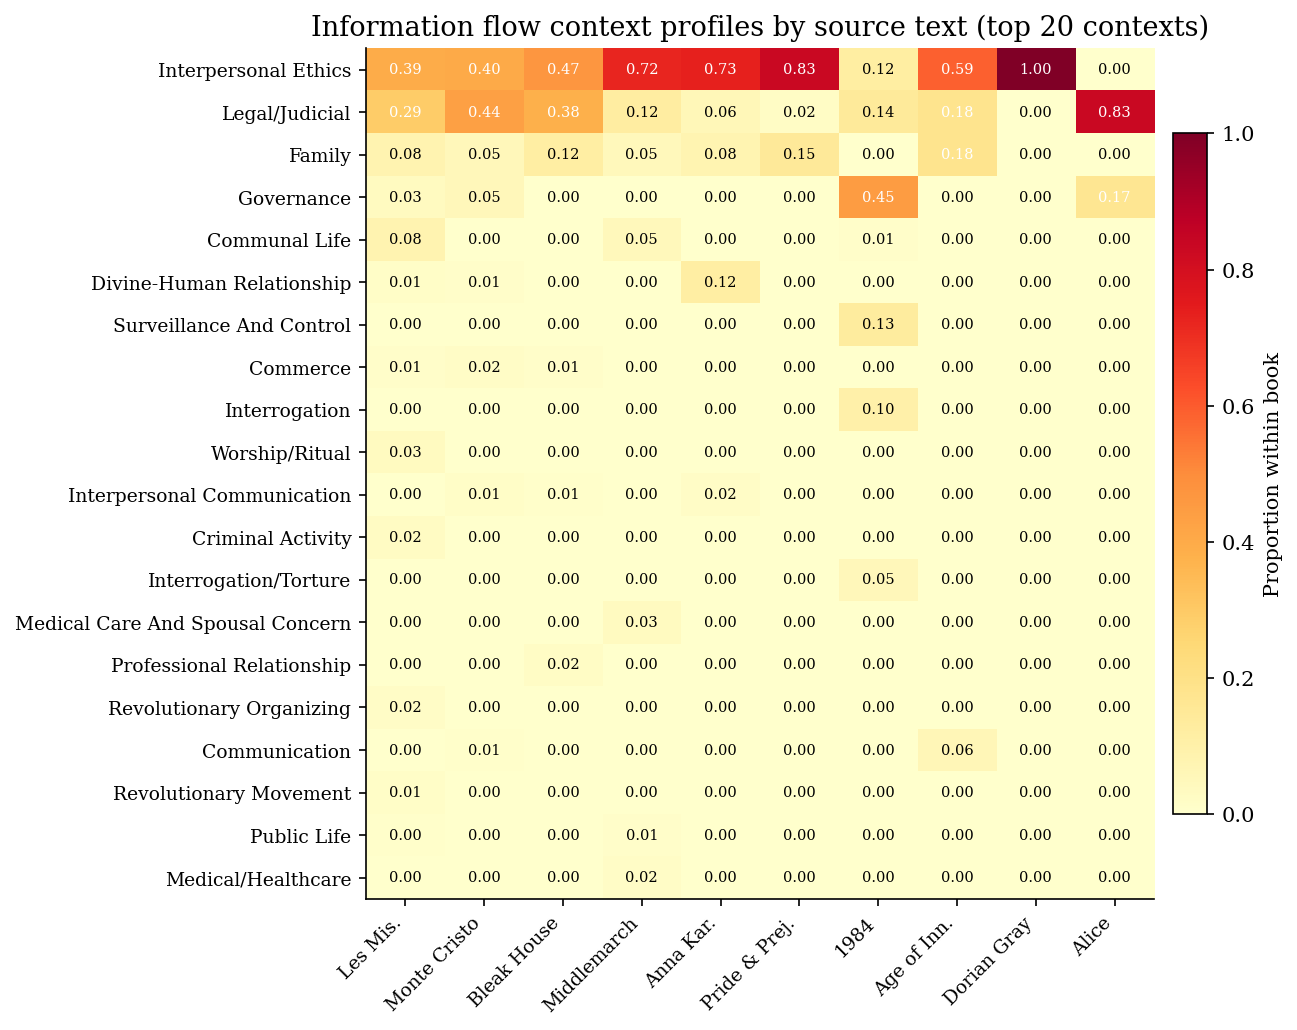

In [9]:
# ── Fig 3b: Top 20 flow contexts × book heatmap ──
top20_flow_labels = top_flow_ctx.index.tolist()

cross_flow_ctx = pd.crosstab(flows["context"], flows["book_title"])
cross_flow_ctx = cross_flow_ctx.reindex(index=top20_flow_labels, columns=BOOK_ORDER).fillna(0)

# Normalize per-book
cross_flow_pct = cross_flow_ctx.div(cross_flow_ctx.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cross_flow_pct.values, cmap=CMAP_WARM, aspect="auto")

ax.set_xticks(range(len(BOOK_ORDER)))
ax.set_xticklabels([BOOK_SHORT[b] for b in BOOK_ORDER], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(top20_flow_labels)))
ax.set_yticklabels([c.title() for c in top20_flow_labels], fontsize=9)

for i in range(len(top20_flow_labels)):
    for j in range(len(BOOK_ORDER)):
        val = cross_flow_pct.values[i, j]
        if not np.isnan(val):
            color = "white" if val > 0.15 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Proportion within book", fontsize=10)
ax.set_title("Information flow context profiles by source text (top 20 contexts)")
plt.tight_layout()
fig.savefig(FIG_DIR / "flow_contexts_by_book_heatmap.pdf")
plt.show()

---
## 4. Cross-Cutting Analyses

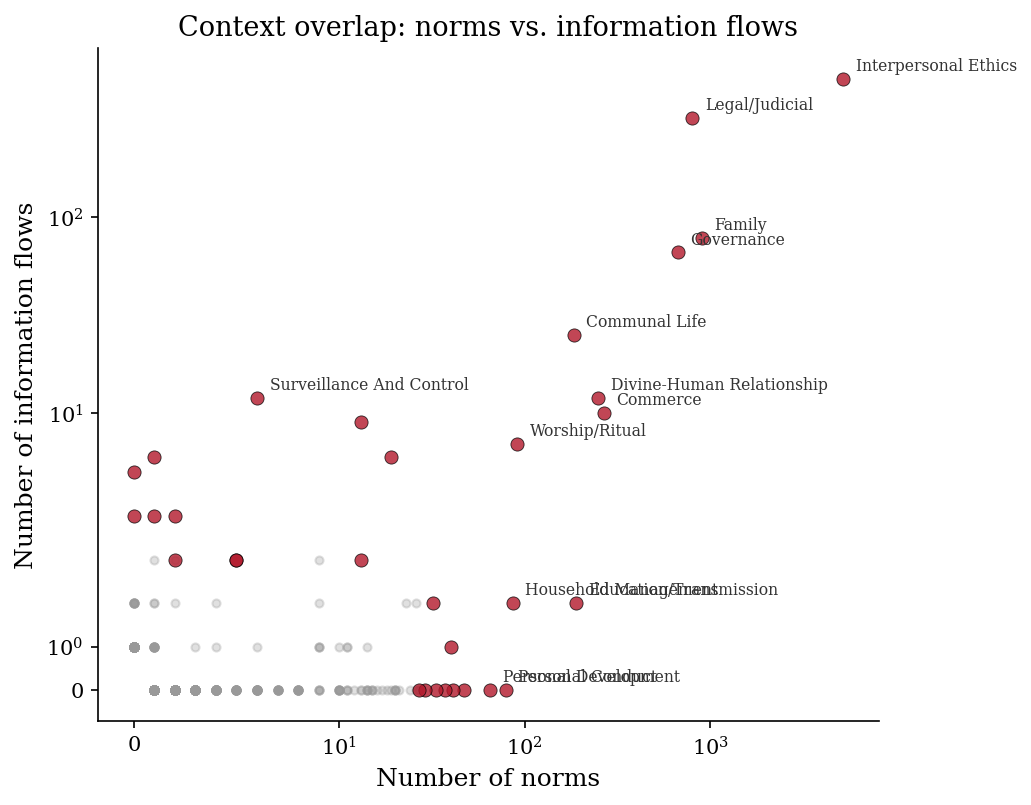

In [10]:
# ── Fig 4a: Norm vs. Flow context overlap (scatter) ──
# For each context, plot norm count vs flow count
norm_ctx_counts = norms["context"].value_counts().rename("norms")
flow_ctx_counts = flows["context"].value_counts().rename("flows")
ctx_both = pd.concat([norm_ctx_counts, flow_ctx_counts], axis=1).fillna(0)

# Keep contexts that appear in at least one of the top-20 lists
highlight = set(top_norm_ctx.index[:20]) | set(top_flow_ctx.index[:20])
ctx_both["highlight"] = ctx_both.index.isin(highlight)

fig, ax = plt.subplots(figsize=(7, 5.5))

# Background points
bg = ctx_both[~ctx_both["highlight"]]
ax.scatter(bg["norms"], bg["flows"], s=15, alpha=0.3, color="#999999", zorder=1)

# Highlighted points
fg = ctx_both[ctx_both["highlight"]]
ax.scatter(fg["norms"], fg["flows"], s=40, alpha=0.8, color="#b2182b", edgecolors="black",
           linewidth=0.4, zorder=2)

# Label the top ones
for ctx in fg.index:
    nx, fx = fg.loc[ctx, "norms"], fg.loc[ctx, "flows"]
    if nx > 50 or fx > 10:
        ax.annotate(
            ctx.title(), (nx, fx),
            textcoords="offset points", xytext=(6, 4),
            fontsize=7.5, color="#333333",
        )

ax.set_xlabel("Number of norms")
ax.set_ylabel("Number of information flows")
ax.set_title("Context overlap: norms vs. information flows")
ax.set_xscale("symlog", linthresh=10)
ax.set_yscale("symlog", linthresh=5)
plt.tight_layout()
fig.savefig(FIG_DIR / "norm_flow_context_scatter.pdf")
plt.show()

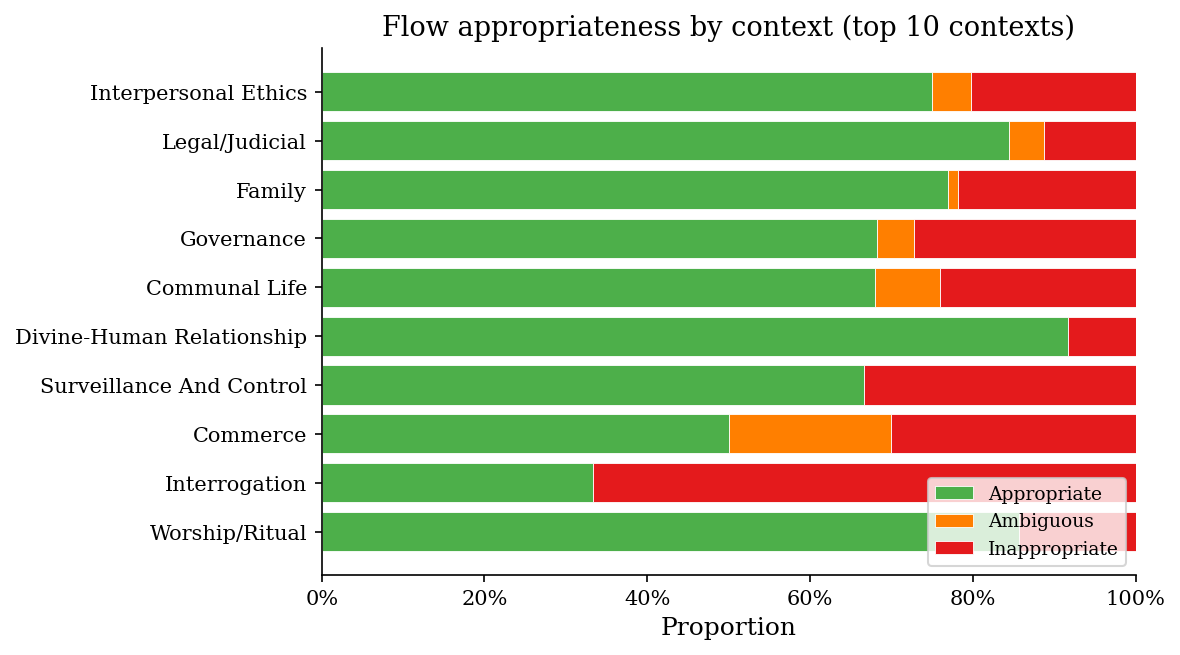

In [11]:
# ── Fig 4b: Flow appropriateness by top contexts ──
flows["appropriateness"] = flows["ci_appropriateness"].str.strip().str.lower()
top10_flow_ctx = top_flow_ctx.index[:10].tolist()

approp_cross = pd.crosstab(
    flows[flows["context"].isin(top10_flow_ctx)]["context"],
    flows[flows["context"].isin(top10_flow_ctx)]["appropriateness"],
)
approp_order = ["appropriate", "ambiguous", "inappropriate"]
approp_cross = approp_cross.reindex(columns=approp_order, fill_value=0)
approp_cross = approp_cross.reindex(index=top10_flow_ctx)
approp_pct = approp_cross.div(approp_cross.sum(axis=1), axis=0)

approp_colors = {"appropriate": "#4daf4a", "ambiguous": "#ff7f00", "inappropriate": "#e41a1c"}

fig, ax = plt.subplots(figsize=(8, 4.5))
left = np.zeros(len(top10_flow_ctx))
for cat in approp_order:
    vals = approp_pct[cat].values
    ax.barh(
        range(len(top10_flow_ctx)), vals, left=left,
        color=approp_colors[cat], edgecolor="white", linewidth=0.4,
        label=cat.capitalize(),
    )
    left += vals

ax.set_yticks(range(len(top10_flow_ctx)))
ax.set_yticklabels([c.title() for c in top10_flow_ctx], fontsize=10)
ax.set_xlabel("Proportion")
ax.set_title("Flow appropriateness by context (top 10 contexts)")
ax.legend(loc="lower right", frameon=True)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG_DIR / "flow_appropriateness_by_context.pdf")
plt.show()

/tmp/ipykernel_2649849/3737162082.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  norm_ent = norms.groupby("book_title").apply(context_entropy).reindex(BOOK_ORDER).rename("Norms")
/tmp/ipykernel_2649849/3737162082.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flow_ent = flows.groupby("book_title").apply(context_entropy).reindex(BOOK_ORDER).rename("Flows")


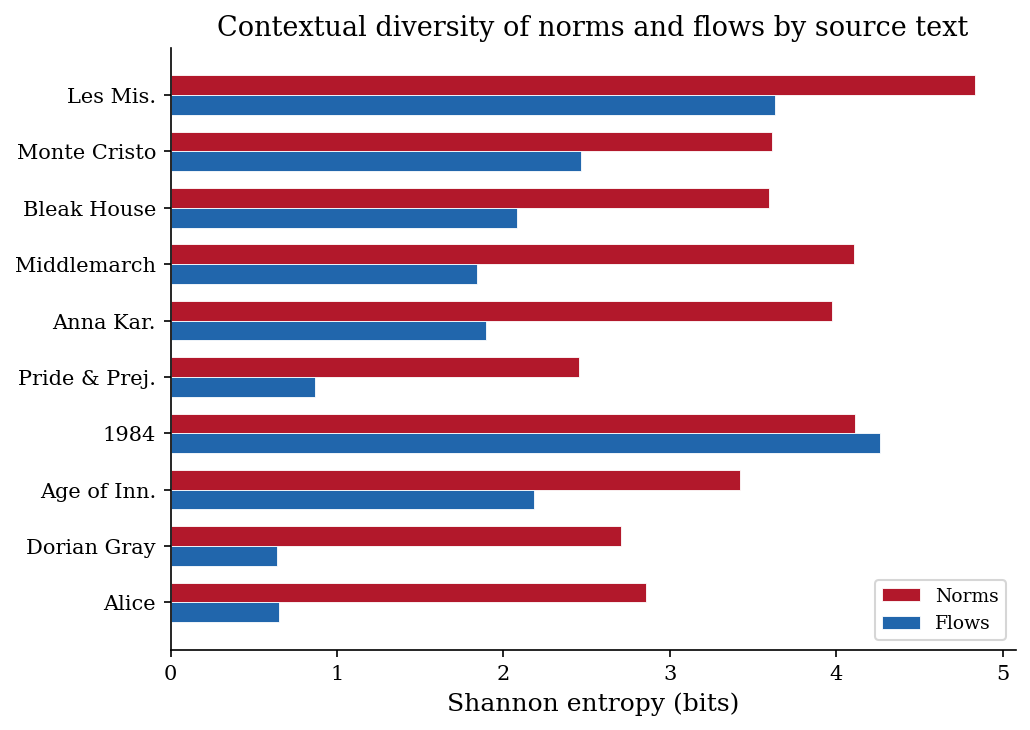

,Norms,Flows
book_title,,
Les Misérables,4.834714,3.628686
The Count of Monte Cristo,3.615111,2.466359
Bleak House,3.596985,2.079145
Middlemarch,4.105420,1.842508
Anna Karenina,3.973373,1.897879
Pride and Prejudice,2.454107,0.869228
Nineteen Eighty-Four,4.112835,4.259765
The Age of Innocence,3.423937,2.185475
The Picture of Dorian Gray,2.706471,0.640206


In [12]:
# ── Fig 4c: Normative diversity per book (Shannon entropy of context distribution) ──
def context_entropy(group):
    """Shannon entropy (base 2) of the context distribution."""
    counts = group["context"].value_counts()
    probs = counts / counts.sum()
    return entropy(probs, base=2)

norm_ent = norms.groupby("book_title").apply(context_entropy).reindex(BOOK_ORDER).rename("Norms")
flow_ent = flows.groupby("book_title").apply(context_entropy).reindex(BOOK_ORDER).rename("Flows")
ent_df = pd.concat([norm_ent, flow_ent], axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(BOOK_ORDER))
w = 0.35
ax.barh(x - w/2, ent_df["Norms"].values, height=w, color="#b2182b", edgecolor="white",
        linewidth=0.4, label="Norms")
ax.barh(x + w/2, ent_df["Flows"].values, height=w, color="#2166ac", edgecolor="white",
        linewidth=0.4, label="Flows")

ax.set_yticks(x)
ax.set_yticklabels([BOOK_SHORT[b] for b in BOOK_ORDER])
ax.set_xlabel("Shannon entropy (bits)")
ax.set_title("Contextual diversity of norms and flows by source text")
ax.legend(loc="lower right", frameon=True)
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG_DIR / "context_entropy_by_book.pdf")
plt.show()

ent_df

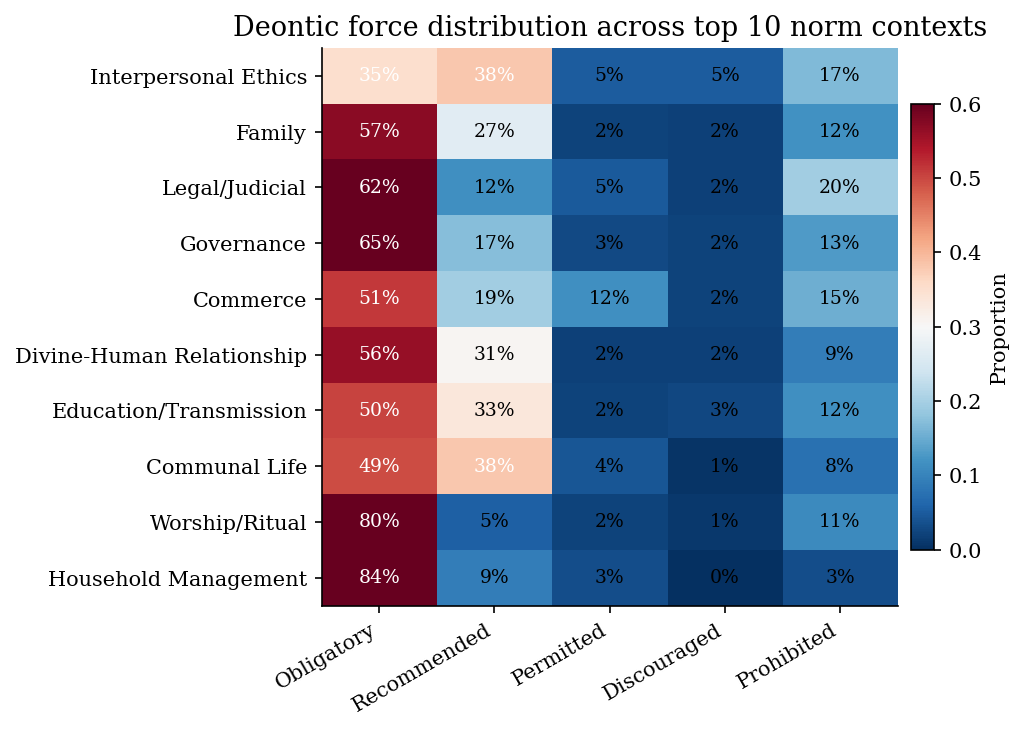

In [13]:
# ── Fig 4d: Deontic force × context heatmap (top 10 contexts) ──
top10_norm_ctx = top_norm_ctx.index[:10].tolist()
deontic_ctx = pd.crosstab(
    norms[norms["context"].isin(top10_norm_ctx)]["context"],
    norms[norms["context"].isin(top10_norm_ctx)]["deontic"],
)
deontic_ctx = deontic_ctx.reindex(index=top10_norm_ctx, columns=DEONTIC_ORDER).fillna(0)
deontic_ctx_pct = deontic_ctx.div(deontic_ctx.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(deontic_ctx_pct.values, cmap="RdBu_r", aspect="auto", vmin=0, vmax=0.6)

ax.set_xticks(range(len(DEONTIC_ORDER)))
ax.set_xticklabels([d.capitalize() for d in DEONTIC_ORDER], rotation=30, ha="right")
ax.set_yticks(range(len(top10_norm_ctx)))
ax.set_yticklabels([c.title() for c in top10_norm_ctx], fontsize=10)

for i in range(len(top10_norm_ctx)):
    for j in range(len(DEONTIC_ORDER)):
        val = deontic_ctx_pct.values[i, j]
        color = "white" if val > 0.35 else "black"
        ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=9, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Proportion", fontsize=10)
ax.set_title("Deontic force distribution across top 10 norm contexts")
plt.tight_layout()
fig.savefig(FIG_DIR / "deontic_by_context_heatmap.pdf")
plt.show()

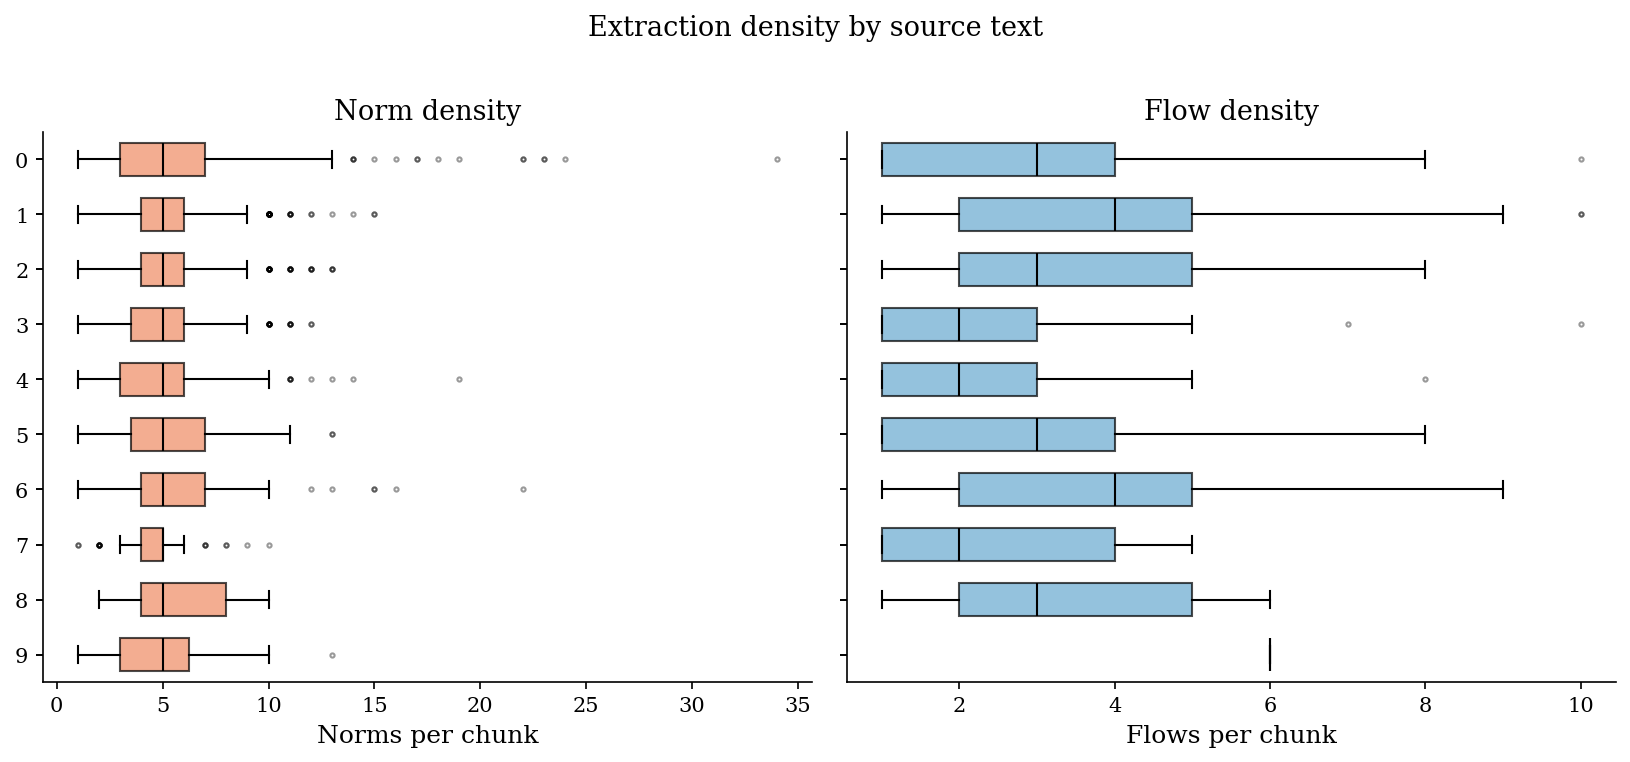

In [14]:
# ── Fig 4e: Norm density (norms per chunk) by book ──
norms_per_chunk = norms.groupby(["book_title", "chunk_id"]).size().reset_index(name="n_norms")
flows_per_chunk = flows.groupby(["book_title", "chunk_id"]).size().reset_index(name="n_flows")

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

# Norms per chunk
for i, book in enumerate(BOOK_ORDER):
    data = norms_per_chunk[norms_per_chunk["book_title"] == book]["n_norms"]
    axes[0].boxplot(
        data, positions=[i], widths=0.6, vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="#ef8a62", alpha=0.7),
        medianprops=dict(color="black"),
        flierprops=dict(markersize=2, alpha=0.4),
    )

axes[0].set_yticks(range(len(BOOK_ORDER)))
axes[0].set_yticklabels([BOOK_SHORT[b] for b in BOOK_ORDER])
axes[0].set_xlabel("Norms per chunk")
axes[0].set_title("Norm density")
axes[0].invert_yaxis()

# Flows per chunk
for i, book in enumerate(BOOK_ORDER):
    data = flows_per_chunk[flows_per_chunk["book_title"] == book]["n_flows"]
    if len(data) > 0:
        axes[1].boxplot(
            data, positions=[i], widths=0.6, vert=False,
            patch_artist=True,
            boxprops=dict(facecolor="#67a9cf", alpha=0.7),
            medianprops=dict(color="black"),
            flierprops=dict(markersize=2, alpha=0.4),
        )

axes[1].set_xlabel("Flows per chunk")
axes[1].set_title("Flow density")
fig.suptitle("Extraction density by source text", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "extraction_density_by_book.pdf")
plt.show()

In [15]:
# ── Summary statistics table ──
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Total norms: {len(norms):,}")
print(f"Total flows: {len(flows):,}")
print(f"Norm/flow ratio: {len(norms)/len(flows):.1f}:1")
print(f"Unique norm contexts: {norms['context'].nunique()}")
print(f"Unique flow contexts: {flows['context'].nunique()}")
print()
print("Top context concentration (norms):")
top1_share = top_norm_ctx.iloc[0] / len(norms)
top5_share = top_norm_ctx.iloc[:5].sum() / len(norms)
print(f"  Top-1 ({top_norm_ctx.index[0]}): {top1_share:.1%}")
print(f"  Top-5: {top5_share:.1%}")
print()
print("Flow appropriateness overall:")
print(flows["appropriateness"].value_counts(normalize=True).to_string())

SUMMARY
Total norms: 11,869
Total flows: 1,241
Norm/flow ratio: 9.6:1
Unique norm contexts: 1065
Unique flow contexts: 148

Top context concentration (norms):
  Top-1 (interpersonal ethics): 44.2%
  Top-5: 66.5%

Flow appropriateness overall:
appropriateness
appropriate      0.779210
inappropriate    0.177276
ambiguous        0.043513


---
### Figures saved to `papers/colm26_normative-simulacra/figures/`:
- `deontic_force_overall.pdf` — Bar chart of deontic force distribution
- `deontic_force_by_book.pdf` — Normalized stacked bar of deontic composition per book
- `norm_contexts_top20.pdf` — Top 20 norm contexts (horizontal bar)
- `norm_contexts_by_book_heatmap.pdf` — Context × book heatmap (norms)
- `flow_contexts_top20.pdf` — Top 20 flow contexts (horizontal bar)
- `flow_contexts_by_book_heatmap.pdf` — Context × book heatmap (flows)
- `norm_flow_context_scatter.pdf` — Norm vs. flow count per context
- `flow_appropriateness_by_context.pdf` — Appropriateness breakdown by context
- `context_entropy_by_book.pdf` — Contextual diversity (Shannon entropy)
- `deontic_by_context_heatmap.pdf` — Deontic force × context heatmap
- `extraction_density_by_book.pdf` — Norms/flows per chunk boxplots